This notebook fits by-cre models on the shendure data & demonstrates that estimated nb parameters track closely with UMI means, as expected.

The matrix-creation and fitting code is independent of the main scMPRA package, since its this analysis that informed the package code.

# Setup

In [ ]:
#imports
import pandas as pd
import numpy as np
import time
import pickle
from formulaic import Formula
import seaborn as sns
import matplotlib.pyplot as plt

from tensorzinb.tensorzinb import TensorZINB
import scMPRAforge as scm

2025-08-13 12:11:15.718587: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-13 12:11:16.568833: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-08-13 12:11:16.568860: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
#create dask cluster

from dask_jobqueue import SLURMCluster
from dask.distributed import Client

cluster=SLURMCluster(
    cores=4,#cores per slurm job
    memory="16G",#memory per slurm job
    processes=4,#dask workers per slurm job
    job_extra_directives=["-p ycga", 
        f"--job-name=simclust_worker",
        f"--time=4:00:00",
        f"--output=slave_%j.out"]
)

cluster.scale(jobs=4)

client = Client(cluster,
        timeout=f"{5*60}s",   # Client <-> scheduler timeout 
        heartbeat_interval="20s"  # Worker heartbeat interval
    )

#from dask.distributed import Client, LocalCluster
#cluster=LocalCluster(memory_limit='8GB')
#client = Client(cluster)

# Describe with an ortho

In [13]:
path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="ortho_primordial_v3"
data_root="/gpfs/gibbs/pi/reilly/tabula_data"

import os
if os.path.isdir(path+"/"+name):
    print("[+] Model found. Loading...")
    primordial=scm.ortho.load(client,path,name)
    shendure=primordial.training_data
else:
    print("[+] Model not found. Creating...")

    #load data
    shendure=scm.scMPRA_data.from_tsv(f"{data_root}/shendure/shendure_counts_not_grouped.txt")
    shendure.set_negative_controls(["minP","noP"])
    shendure.set_reference_cell("Pluripotent")
    shendure.ortho_filter()

    primordial=scm.ortho()
    primordial.criss_cross(client=client,
                       dat=shendure)
    primordial.extract_params(client)
    primordial.save(path,name)


[+] Model not found. Creating...


scMPRAforge: INFO: Dropped 371 of 1833 (cell_type, cre_id) combos with fewer than 3 nonzero entries.


In [14]:
primordial.compute_model_qc()

In [15]:
by_cre_thetas=[]
for key in primordial.by_cre.model:
    by_cre_thetas.append(primordial.by_cre.model[key].result()["weights"]["theta"].squeeze())
by_cre_thetas=np.array(by_cre_thetas)

by_cell_type_thetas=[]
for key in primordial.by_cell_type.model:
    by_cell_type_thetas.append(primordial.by_cell_type.model[key].result()["weights"]["theta"].squeeze())
by_cell_type_thetas=np.array(by_cell_type_thetas)


<Axes: >

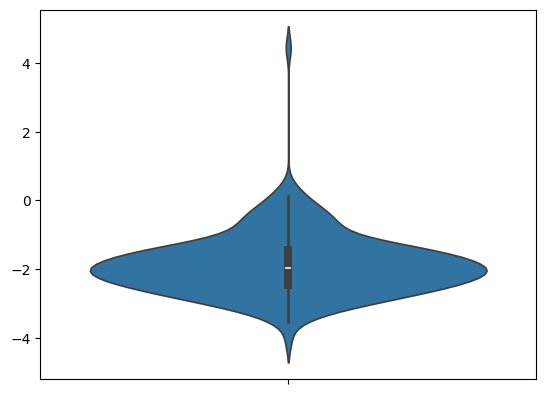

In [16]:
sns.violinplot(by_cre_thetas)

<Axes: >

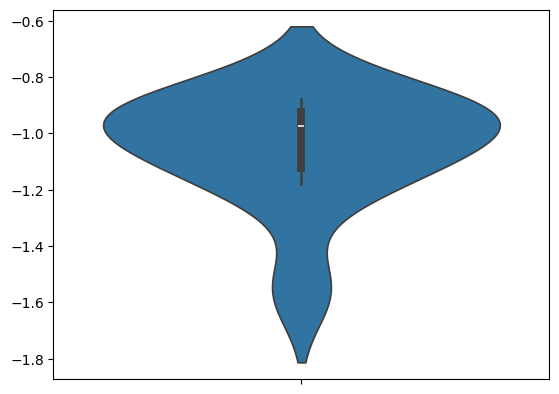

In [17]:
sns.violinplot(by_cell_type_thetas)

In [18]:
np.mean(by_cre_thetas)

-1.8729738

In [19]:
np.mean(by_cell_type_thetas)

-1.0543859

In [20]:
np.mean(np.concatenate((by_cre_thetas,by_cell_type_thetas)))

-1.8354238

# Extract bounds

Roughly how many cells per cre X cell-type X replicate combo?

We'll start by loading unfiltered data.

In [25]:
shendure_unfiltered=scm.scMPRA_data.from_tsv(f"{data_root}/shendure/shendure_counts_not_grouped.txt")

In [26]:
shendure_unfiltered.data

,cell_bc,rep_id,transfection_bc,mpra_bc,cre_class,cre_id,reads_transfection_bc,umis_transfection_bc,reads_mpra_bc,umis_mpra_bc,cell_type,gex_umi,normalized_umis_mpra_bc
0,A1_GTTACCCAGTTGAAGT-1,A1,GAAAGTGTATTTGGGT,ACGTAACATTATAAT,devCRE,Txndc12_chr4_7978,499,415,0,0,SurfaceEctoderm,3913,0.000000
1,A1_GTTACCCAGTTGAAGT-1,A1,CCGGGGTAGGCGAAGA,AACTCAGACTACCAC,devCRE,Col1a2_chr6_72,510,414,0,0,SurfaceEctoderm,3913,0.000000
2,A1_GTTACCCAGTTGAAGT-1,A1,ACTGACGTCAATCAAT,TGTTTAAGTCAACAA,devCRE,Klf4_chr4_3952,850,678,0,0,SurfaceEctoderm,3913,0.000000
3,A1_GTTACCCAGTTGAAGT-1,A1,GGAGGTGTGCGCGTGG,CAACAACACATTTTA,devCRE,Foxa2_chr2_13840,549,451,0,0,SurfaceEctoderm,3913,0.000000
4,A1_GTTACCCAGTTGAAGT-1,A1,CGATACCTACTTAATA,TACCTAATGGGAAAG,promoters,minP,413,353,0,0,SurfaceEctoderm,3913,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
877059,2B2_TTCTGTAAGGCTCTCG-1,2B2,AGCTGGTACACCCGAG,GAACAATTAAACGAG,devCRE,Sparc_chr11_7198,55,50,0,0,NeuroectodermRostral,522,0.000000
877060,2B2_TTCTGTAAGGCTCTCG-1,2B2,ATTTAGACACCAATAC,CAGCCCGCCGCCGAG,promoters,ubcP,32,31,196,11,NeuroectodermRostral,522,63.118754
877061,2B2_TGGAACTCAATCCTAG-1,2B2,GTTAGATACGCTATGG,ATGGCACATATCTTA,devCRE,Gata4_chr14_5760,21,18,0,0,Mesoderm,968,0.000000
877062,2B2_TGGAACTCAATCCTAG-1,2B2,GATTAATTCGGTCTAC,CTCTATCGTCCTCGT,devCRE,Lamb1_chr12_2289,13,13,0,0,Mesoderm,968,0.000000


Now calculate the number of MPRA barcodes per cell

<Axes: xlabel='mpra_bc', ylabel='Count'>

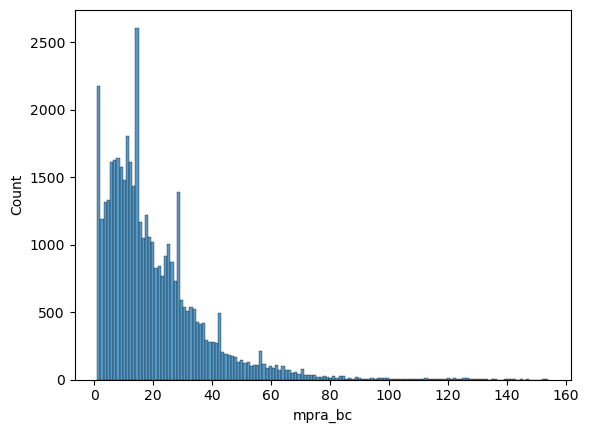

In [ ]:
unique_mpra_barcodes_per_cell=shendure_unfiltered.data.groupby("cell_bc")["mpra_bc"].nunique()
sns.histplot(unique_mpra_barcodes_per_cell)

In [55]:
import statsmodels.api as sm
import statsmodels.discrete.discrete_model as smd

import scipy

cell_bc
2B1_AAACCCACAAGGTTGG-1    10
2B1_AAACCCACACTTGAAC-1    26
2B1_AAACCCACAGTCGCTG-1     6
2B1_AAACCCAGTAACAGTA-1    36
2B1_AAACCCAGTATCAAGA-1    33
                          ..
B2_TTTGTTGAGTATGACA-1      8
B2_TTTGTTGCAACTAGAA-1     19
B2_TTTGTTGCAATCTAGC-1      5
B2_TTTGTTGCATTGAGGG-1      5
B2_TTTGTTGGTGGACCAA-1     19
Name: mpra_bc, Length: 38773, dtype: int64

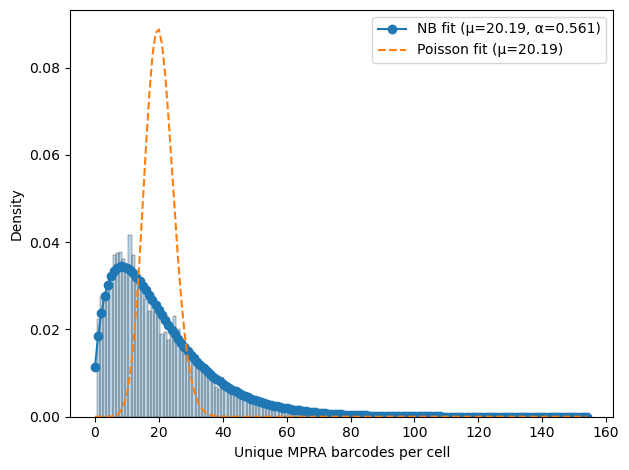

In [62]:
# data
y = np.asarray(unique_mpra_barcodes_per_cell, dtype=int)
#y = np.asarray(unique_mpra_barcodes_per_cell[unique_mpra_barcodes_per_cell<40], dtype=int)

# intercept-only design
X = np.ones((len(y), 1))

# --- Fit Poisson (discrete) ---
pois = smd.Poisson(y, X).fit(disp=False)
mu_pois = np.exp(pois.params[0])      # intercept-only mean

# --- Fit Negative Binomial NB2 (discrete) ---
# Var = mu + alpha*mu^2, alpha is estimated
nb = smd.NegativeBinomial(y, X).fit(disp=False)
mu_nb = np.exp(nb.params[0])          # intercept-only mean
alpha_nb = nb.params[-1]              # dispersion (NB2 alpha)

# Convert NB2 (mu, alpha) -> scipy's nbinom (r, p)
r = 1.0 / alpha_nb                    # "size"
p = r / (r + mu_nb)                   # success prob

# Grid for PMFs
k = np.arange(0, y.max() + 1)
pmf_nb = scipy.stats.nbinom.pmf(k, r, p)
pmf_pois = scipy.stats.poisson.pmf(k, mu_pois)

# --- Plot ---
fig, ax = plt.subplots()
sns.histplot(
    y,
    bins=np.arange(y.min(), y.max() + 2),
    stat="density", discrete=True, alpha=0.3, ax=ax
)
ax.plot(k, pmf_nb, marker='o', linestyle='-', label=f'NB fit (μ={mu_nb:.2f}, α={alpha_nb:.3f})')
ax.plot(k, pmf_pois, linestyle='--', label=f'Poisson fit (μ={mu_pois:.2f})')
ax.set_xlabel('Unique MPRA barcodes per cell')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

In [66]:
nb.converged

True

In [63]:
np.mean(unique_mpra_barcodes_per_cell)

20.1869864432527

In [64]:
np.var(unique_mpra_barcodes_per_cell)

281.76373333337034

In [37]:
#Let's get a description of 

import statsmodels.api as sm
from statsmodels.discrete.count_model import NegativeBinomialP

model = NegativeBinomialP(unique_barcodes_per_combo, exog=np.ones(len(unique_barcodes_per_combo)))
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 5.134870
         Iterations: 5
         Function evaluations: 7
         Gradient evaluations: 7
                     NegativeBinomialP Regression Results                     
Dep. Variable:                cell_bc   No. Observations:                12556
Model:              NegativeBinomialP   Df Residuals:                    12555
Method:                           MLE   Df Model:                            0
Date:                Fri, 25 Jul 2025   Pseudo R-squ.:               6.713e-12
Time:                        16:26:14   Log-Likelihood:                -64473.
converged:                       True   LL-Null:                       -64473.
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1268      0.009    458.9

In [29]:
by_cre_thetas=[]
for key in primordial.by_cre.model:
    by_cre_thetas.append(primordial.by_cre.model[key].result()["weights"]["theta"].squeeze())
by_cre_thetas=np.array(by_cre_thetas)

by_cell_type_thetas=[]
for key in primordial.by_cell_type.model:
    by_cell_type_thetas.append(primordial.by_cell_type.model[key].result()["weights"]["theta"].squeeze())
by_cell_type_thetas=np.array(by_cell_type_thetas)


<Axes: >

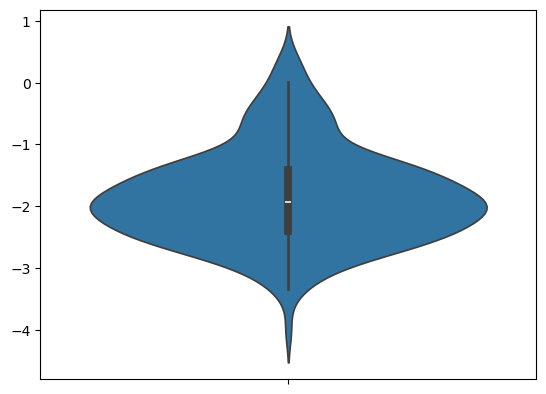

In [30]:
sns.violinplot(by_cre_thetas)

<Axes: >

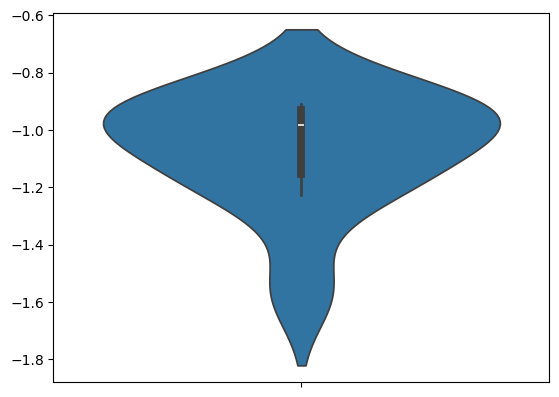

In [31]:
sns.violinplot(by_cell_type_thetas)

In [32]:
np.mean(by_cre_thetas)

-1.8434663

In [33]:
np.mean(by_cell_type_thetas)

-1.0747712

In [37]:
np.mean(np.concatenate((by_cre_thetas,by_cell_type_thetas)))

-1.8082051

# Examine QC metrics

Now that we've generated some QC metrics, let's examine them. First, let's look at the mu min & max : none should be below zero, none should be above 1000.

In [21]:
def minimax(QC):
    x=[]
    for level in QC.keys():
        if QC[level]["success"]:
            x.append(QC[level]["dat"])
    x=pd.concat(x)
    print(f"min {min(x['mu'])}, max {max(x['mu'])}")

print("cre")
minimax(primordial.by_cre_qc)
print("ct")
minimax(primordial.by_cell_qc)

cre
min 0.004903659182848444, max 369.88473782763344
ct
min 0.0034641979561541277, max 343.27339601642825


All in the right ballpark!

Now let's look at the correlations.

---
low r Cdk5r1_chr11_12595
low r Lamb1_chr12_2206
nan in Txndc12_chr4_7969
low r Lamc1_chr1_12183
---
[0.9998314507932474, 0.9999954315660934, 0.9999724537546907, 0.9999728557541269, 0.9998250668289967, 0.9993628294465893, 0.9999997549521233, 0.9996073115551575, 0.9996110634579647, 0.9990296009650044, 0.9950273535724214, 0.9999995837777036, 0.9997239150583507, 0.9988201905486462, 0.9998226908791837, 0.9994558653172501, 0.9990546696226931, 0.9969510762775178, 0.9996616974566801, 0.9997163372439175, 0.9999641176241476, 0.9978663748558305, 0.9999380466979719, 0.9973530775606525, 0.984224970923368, 0.9997966248172353, 0.9999494388309236, 0.9989163915628878, 0.9965739033542026, 0.9996848587078161, 0.9673993333135112, 0.9985089692181061, 0.9996644703166618, 0.9998281624663683, 0.9928873137665467, 0.9999361399254716, 0.9999999712683614, 0.9990970773555194, 0.9996223797197846, 0.9967822165594049, 0.9990930995579446, 0.9999921502292602, 0.9977557515972786, 0.999457942115386, 0.996906262821856

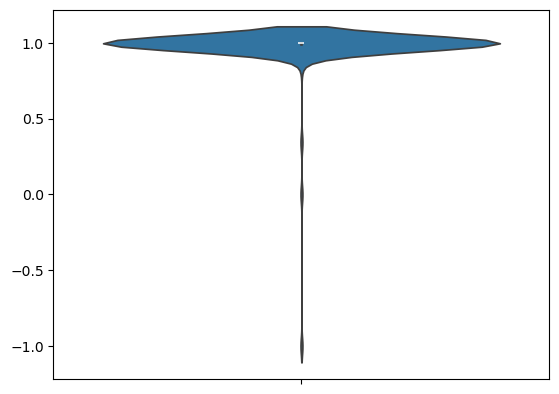

In [22]:
r=[]
for QC in [primordial.by_cre_qc,primordial.by_cell_qc]:
    print("---")
    
    for level in QC.keys():
        if QC[level]["success"]:
            if np.isnan(QC[level]["r_value"]):
                print(f"nan in {level}")
            else:
                if QC[level]["r_value"]<0.8:
                    print(f"low r {level}")
                r.append(QC[level]["r_value"])


sns.violinplot(r)

print(r)
#print(np.mean(r))
#for cell_type in QC:
#    print(f"{cell_type} : r={QC[cell_type]['r_value']}, slope={QC[cell_type]['slope']}")

Correlations generally look pretty good. Let's examine the cases where they aren't.

Notably all of the bad ones are from the set of "by cell-type" models.

I'm going to guess these are low-expressing CREs. Let's take a look.

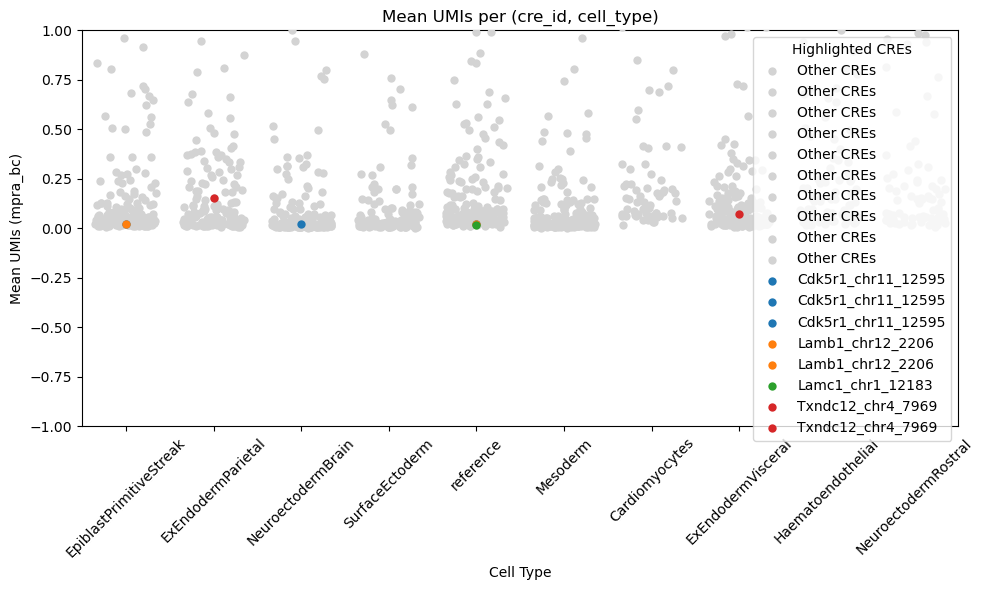

In [23]:
highlighted_cre_ids=["Cdk5r1_chr11_12595","Lamb1_chr12_2206","Lamc1_chr1_12183","Txndc12_chr4_7969"]

grouped = (
    shendure.data
    .groupby(["cre_id", "cell_type"])["umis_mpra_bc"]
    .mean()
    .reset_index()
)

# Split base vs. highlighted
base = grouped[~grouped["cre_id"].isin(highlighted_cre_ids)]
highlighted = grouped[grouped["cre_id"].isin(highlighted_cre_ids)]

# Set up plot
plt.figure(figsize=(10, 6))

# Plot base layer with jitter
sns.stripplot(
    data=base,
    x="cell_type",
    y="umis_mpra_bc",
    color="lightgray",
    jitter=0.35,
    label="Other CREs",
    size=6
)

# Overlay highlighted CREs with jitter and custom color
palette = sns.color_palette("tab10", n_colors=len(highlighted_cre_ids))
for i, cre in enumerate(highlighted_cre_ids):
    sns.stripplot(
        data=highlighted[highlighted["cre_id"] == cre],
        x="cell_type",
        y="umis_mpra_bc",
        color=palette[i],
        jitter=0.35,
        label=cre,
        size=6
    )

# Y-axis and aesthetics
plt.ylim(-1, 1)
plt.xlabel("Cell Type")
plt.ylabel("Mean UMIs (mpra_bc)")
plt.title("Mean UMIs per (cre_id, cell_type)")
plt.xticks(rotation=45)
plt.legend(title="Highlighted CREs")
plt.tight_layout()
plt.show()


In [24]:
primordial.by_cre_qc["Cdk5r1_chr11_12595"]

{'success': True,
 'dat':                                mu  mean(umis_mpra_bc)
 cell_type                                            
 EpiblastPrimitiveStreak  0.041301            0.020243
 NeuroectodermBrain       0.044826            0.022358
 reference                0.045337            0.020101,
 'slope': 0.5976541198514547,
 'intercept': 0.03133004063271872,
 'r_value': 0.34375323636314653,
 'p_value': 0.7766032527649439,
 'std_err': 1.6326626999029166}

In [67]:
cluster.close()